In [9]:
import numpy as np
from src.Env import Env
from src.MCTS import MCTS
from src.views import AsciiView
import torch
import os
from tqdm import tqdm
from src.PolicyValueModel import PolicyValueModel
import matplotlib.pyplot as plt

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
model_name = []
models = []

for i in tqdm(range(1, 1001, 100), desc="Loading models"):
    name = f"checkpoints/iteration_{i:04d}.pt"

    if not os.path.exists(name):
        continue

    checkpoint = torch.load(name, map_location=device)
    model = PolicyValueModel().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    model_name.append(name)
    models.append(model)

Loading models: 100%|██████████| 10/10 [00:00<00:00, 224.71it/s]


In [12]:
def fight(model1, model2, verbose=False):
    """
    Model1 wins: returns -1
    Draw: returns 0
    Model2 wins: returns 1
    """
    env = Env()
    mcts1 = MCTS(model1, num_simulations=100, c_puct=1.5, add_exploration_noise=False)
    mcts2 = MCTS(model2, num_simulations=100, c_puct=1.5, add_exploration_noise=False)

    if verbose:
        view = AsciiView(env.game)
        view.update()
        print()
    
    while not env.is_terminal():
        if env.current_player == -1:
            root = mcts1.run(root_env=env)
            pi = mcts1.visit_counts_to_policy(root=root, temperature=0.0)
            action = int(np.argmax(pi))
            env.step(action)
        else:
            root = mcts2.run(root_env=env)
            pi = mcts2.visit_counts_to_policy(root=root, temperature=0.0)
            action = int(np.argmax(pi))
            env.step(action)
        
        if verbose:
            view.update()
            print()
    
    return env.winner()

In [13]:
def compute_new_elos(elo1, elo2, result, k=20):
    expected1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
    expected2 = 1 / (1 + 10 ** ((elo1 - elo2) / 400))

    if result == -1:  # model1 wins
        score1, score2 = 1, 0
    elif result == 0:  # draw
        score1, score2 = 0.5, 0.5
    else:  # model2 wins
        score1, score2 = 0, 1

    new_elo1 = elo1 + k * (score1 - expected1)
    new_elo2 = elo2 + k * (score2 - expected2)

    return new_elo1, new_elo2

In [14]:
elos = [500] * len(models)
N_FIGHTS = 100

for _ in tqdm(range(N_FIGHTS), desc="Fights"):
    idx1, idx2 = np.random.choice(len(models), size=2, replace=False)
    model1, model2 = models[idx1], models[idx2]
    result = fight(model1, model2)
    elos[idx1], elos[idx2] = compute_new_elos(elos[idx1], elos[idx2], result)

Fights: 100%|██████████| 100/100 [03:20<00:00,  2.01s/it]


In [22]:
fight(models[2], models[4])

-1

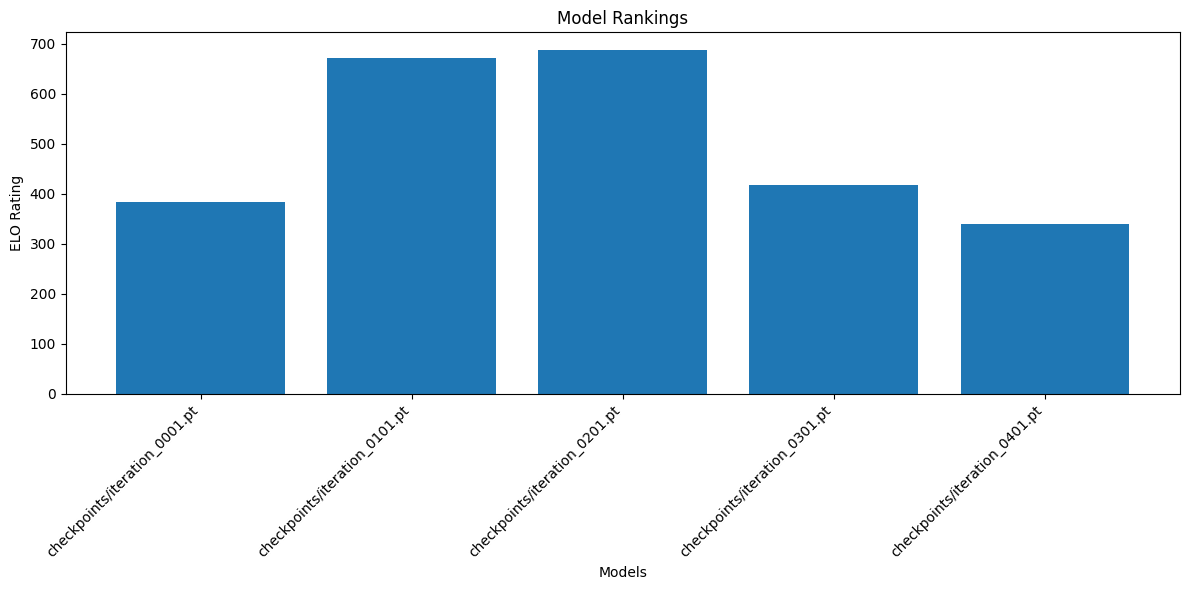

In [15]:
plt.figure(figsize=(12, 6))
plt.bar(model_name, elos)
plt.xlabel("Models")
plt.ylabel("ELO Rating")
plt.title("Model Rankings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()